# Local and full operator-resolved density of states
`get_dos(operator=...)` resolves the k-integrated DOS onto an operator (e.g. per-sublattice
weight), while `get_ldos`/`get_multildos` give the real-space local DOS (single energy or a
whole energy grid, written per-energy under `MULTILDOS/`).
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import islands

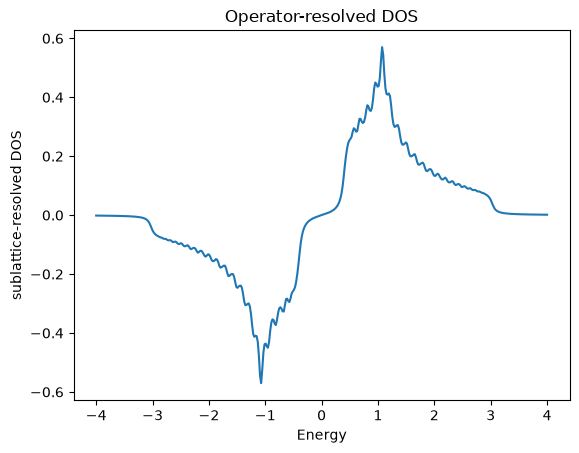

In [2]:
g = geometry.honeycomb_lattice()
h = g.get_hamiltonian(has_spin=True)
h.add_sublattice_imbalance(.4) # break the two sublattices apart in energy
(es,ds) = h.get_dos(operator="sublattice",nk=40,delta=5e-2)

plt.plot(es,ds)
plt.xlabel("Energy") ; plt.ylabel("sublattice-resolved DOS")
plt.title("Operator-resolved DOS")
plt.show()

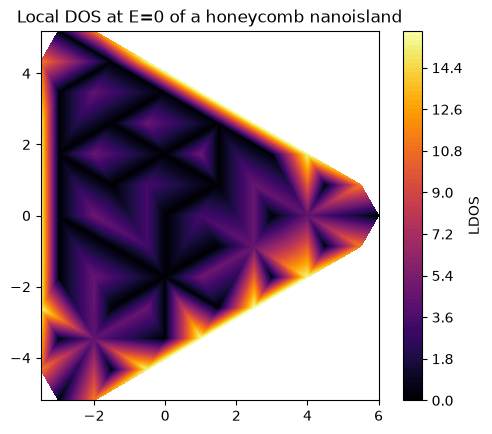

In [3]:
g_isl = islands.get_geometry(name="honeycomb",n=3,nedges=3) # finite flake
h_isl = g_isl.get_hamiltonian()
(x,y,d) = h_isl.get_ldos(e=0.0,delta=1e-2) # real-space LDOS at E=0

plt.tricontourf(x,y,d,levels=100,cmap="inferno")
plt.colorbar(label="LDOS")
plt.gca().set_aspect("equal")
plt.title("Local DOS at E=0 of a honeycomb nanoisland")
plt.show()